# Fig: bifurcation diagram of DMFD
ISHII Hidemasa

In [1]:
using Roots, Polynomials
using CairoMakie
import ColorSchemes as cs

In [2]:
# fixed parameters
r = 0.05
D = 0.005

0.005

## theory
### stochastic mean-field dynamics (SMFD)
Under the assumptions:
- $K - f'(X) \approx K$ [note that $f'(X) \sim r$] 
- $D (1 - 1/N) \approx D$ (i.e. vanishing $1 / N$),  

the effective mean-field dynamics are governed by
\begin{align*}
\frac{dX}{dt} =& -\frac{dV_X}{dX} + \sqrt{\frac{2D}{N}} \eta_X,  \\
V_X(X) =& \frac{1}{4} X^4 - \frac{1 + r}{3} X^3 + \frac{r + 3 Z}{2} X^2 - (1 + r) Z X,  \\
Z =& \frac{D}{K}.
\end{align*}
The drift is
\begin{gather*}
    f(X; Z) = -\frac{dV_X}{dX} = -X^3 + (1 + r) X^2 - (r + 3 Z) X + (1 + r) Z.
\end{gather*}
There always exists a root of $f(X; Z) = 0$ near $X = 1$, corresponding to the state after the escape of the system.
The noise-free system $\dot{X} = f(X; Z)$ is monostable for large enough $Z$ (i.e. small enough $K$).
As $Z$ declines (i.e. $K$ increases), two fixed points appear through a saddle-node bifurcation at the bifurcation point $K_2$, and the system becomes bistable.

### calculating the critical point $K_2$
Let $X_0$ be the position of the minimum of the flow $f(X; Z) = -dV_X / dX$ near $X = 0$.
For
\begin{align*}
& f'(X; Z) = -3X^2 + 2 (1 + r) X - r - 3Z = 0,  \\
& X_\pm = \frac13 \left( 1 + r \pm \sqrt{1 - r + r^2 - 9Z} \right),
\end{align*}
one sees
$$ X_0 = \frac13 \left(1 + r - \sqrt{1 - r + r^2 - 9Z} \right). $$
The critical coupling strength $K_2$ can be obtained numerically by solving
$ f(X_0; Z_2) = 0 $ 
for $Z_2 = D / K_2$. 

In [3]:
Zstar(K; D=D) = D / K

drift_pol(K; r=r, D=D) = Polynomial([
    (1 + r) * Zstar(K, D=D), 
    -(r + 3 * Zstar(K, D=D)),
    1 + r,
    -1
], :X)

drift_pol (generic function with 1 method)

In [4]:
# numerically find K2
K2 = let
    X0(Z; r=r) = (1 + r - sqrt(1 - r + r^2 - 9Z)) / 3
    f(X, Z; r=r) = -X^3 + (1 + r) * X^2 - (r + 3Z) * X + (1 + r) * Z
    f0(Z) = f(X0(Z), Z)

    Z2 = find_zero(f0, (D / 7, D / 9))
    K2 = D / Z2
    println("K2≈", round(K2, digits=6), ",\t Z2≈", round(Z2, digits=8))
    K2
end;

K2≈7.99473,	 Z2≈0.00062541


In [5]:
# new format for axes tick labels on log10 scale
const SUPERSCRIPT_DIGITS = collect("⁰¹²³⁴⁵⁶⁷⁸⁹")
const SUBSCRIPT_DIGITS   = collect("₀₁₂₃₄₅₆₇₈₉")

10-element Vector{Char}:
 '₀': Unicode U+2080 (category No: Number, other)
 '₁': Unicode U+2081 (category No: Number, other)
 '₂': Unicode U+2082 (category No: Number, other)
 '₃': Unicode U+2083 (category No: Number, other)
 '₄': Unicode U+2084 (category No: Number, other)
 '₅': Unicode U+2085 (category No: Number, other)
 '₆': Unicode U+2086 (category No: Number, other)
 '₇': Unicode U+2087 (category No: Number, other)
 '₈': Unicode U+2088 (category No: Number, other)
 '₉': Unicode U+2089 (category No: Number, other)

In [6]:
function superscript(n::Integer)
    if_pos = n >= 0
    if if_pos
        return join(SUPERSCRIPT_DIGITS[begin .+ reverse(digits(n))])
    else
        return "⁻" * join(SUPERSCRIPT_DIGITS[begin .+ reverse(digits(-n))])
    end
end

function log10format(value; digits=3, minabsexp=3)
    exponent = floor(Integer, log10(value))

    if abs(exponent) < minabsexp
        # no formatting for small value
        return "$(round(value, digits=max(1 - exponent, 1)))" 
    end

    coeff = round(value / 10.0^exponent, RoundNearestTiesUp; digits=digits)
    if coeff == 1
        return "10$(superscript(exponent))"
    else
        return "$(coeff)×10$(superscript(exponent))"
    end
end

log10format (generic function with 1 method)

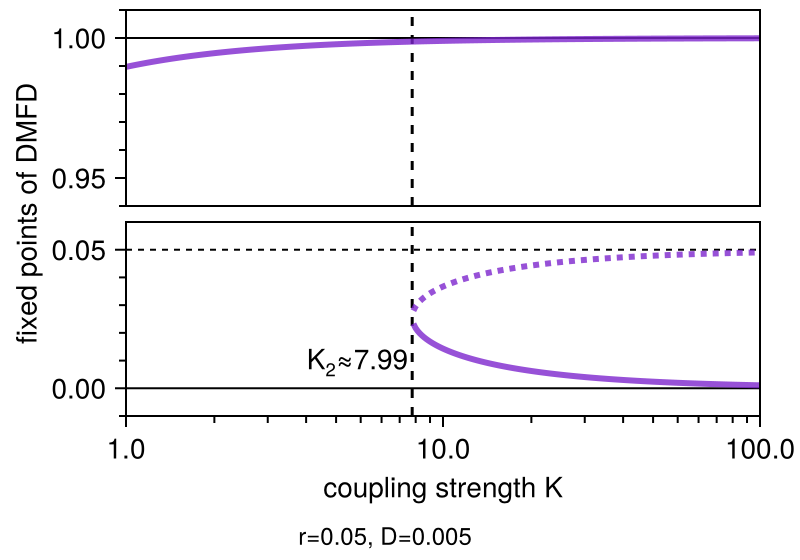

In [7]:
# plot bifurcation diagram
let ifsave=true
    #K_vec = [collect(logrange(1, 8, 31))[begin:end-1]; collect(logrange(8, 25, 31))]
    K_vec = collect(logrange(1, 100, 301))
    # find roots
    real_roots = Vector{Vector{Float64}}(undef, length(K_vec))
    for (j, K) in enumerate(K_vec)
        real_roots[j] = filter(isreal, roots(drift_pol(K)))
    end

    #########
    # # collect K and X* for two stable and one unstable branches
    # upper stable branch
    K_us = Vector{Float64}()  
    fp_us = Vector{Float64}()

    # lower stable branch
    K_ls = Vector{Float64}()  
    fp_ls = Vector{Float64}()

    # unstable branch
    K_un = Vector{Float64}()  
    fp_un = Vector{Float64}()

    for (K, roots) in zip(K_vec, real_roots)
        if length(roots) == 1
            push!(K_us, K)
            push!(fp_us, only(roots))
        elseif length(roots) == 3
            sortedroots = sort(roots)
            push!(K_ls, K)
            push!(fp_ls, sortedroots[1])
            push!(K_un, K)
            push!(fp_un, sortedroots[2])
            push!(K_us, K)
            push!(fp_us, sortedroots[3])
        else
            @warn "unexpected number of roots" len_roots = length(roots)
        end
    end

    ##########
    # # generate Figure
    fig = Figure(size=(400, 280), figure_padding=(5, 20, 5, 5))
    # generate GridLayout
    gl = fig[1, 1] = GridLayout()
    # generate Axes
    Label(gl[1:2, 1], "fixed points of DMFD", rotation=π/2)
    axopts = (
        xautolimitmargin=(0, 0), xscale=log10, xgridvisible=false, 
        ygridvisible=false, yticks=-1:0.05:2, yminorticksvisible=true, yminorticks=IntervalsBetween(5),
    )
    ax1 = Axis(gl[1, 2]; xticksvisible=false, xticklabelsvisible=false, axopts...)
    ax2 = Axis(gl[2, 2]; 
        xlabel="coupling strength K", xtickformat=values -> log10format.(values, digits=2),
        xticks=(10.0).^(-5:5), xminorticksvisible=true, 
        xminorticks=IntervalsBetween(10),
        axopts...
    )
    linkxaxes!(ax1, ax2)
    # set y limit
    ylims!(ax2, -0.01, 0.06)
    ylims!(ax1, 0.94, 1.01)
    # annotate X=0, r, and 1
    hlines!(ax2, r, color=(:black, 1.0), linestyle=:dash, linewidth=1)
    hlines!(ax2, 0, color=(:black, 1.0), linewidth=1)
    hlines!(ax1, 1, color=(:black, 1.0), linewidth=1)
    # annotate K2
    for ax in (ax1, ax2)
        vlines!(ax, K2, color=:black, linestyle=:dash)
    end
    text!(ax2, K2, 0; text=rich("K", subscript("2"), "≈$(round(K2, digits=2))"),
        align=(:right, :bottom), offset=(-2, 4),
    )
    # line plot of branches
    lineopts = (linewidth=3.0, color=(:purple3, 0.8))
    lines!(ax1, K_us, fp_us; linestyle=:solid, lineopts...)
    lines!(ax2, K_ls, fp_ls; linestyle=:solid, lineopts...)
    lines!(ax2, K_un, fp_un; linestyle=(:dot, :dense), lineopts...)
    # adjust margins
    rowgap!(gl, 8)
    colgap!(gl, 5)
    # annotate parameter values
    Label(fig[end+1, :], "r=$r, D=$D", tellwidth=false,
        fontsize=12,
    )
    rowgap!(fig.layout, 10)
    # save figure if needed
    if ifsave save("output/fig-dmfd-bifurcation.pdf", fig) end
    display(fig)
end;